### Loading data

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.cluster.clarans import clarans

from minisom import MiniSom

sns.set()

In [2]:
iris = load_iris()

features = pd.DataFrame(iris.data, columns=iris.feature_names)
targets = iris.target   # true labels, only for reference, not used in clustering


features.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
print(features.shape)
print(features.describe())
print(features.isnull().sum())

(150, 4)
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


### Scaling the data

In [86]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

### PCA

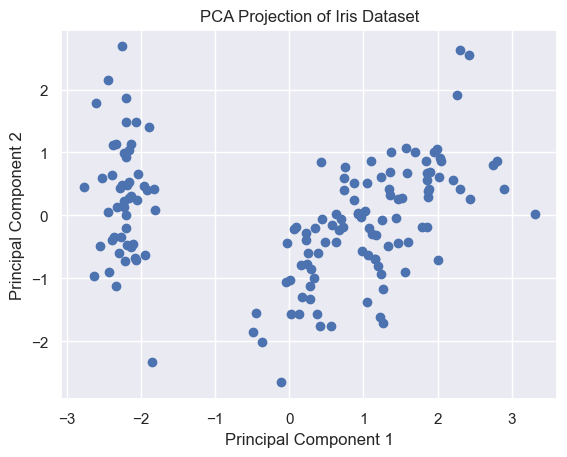

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Iris Dataset")


plt.show()

The graph shows that when we plot the data based on 2 principal components it splits into 2-3 groups.

### Finding Optimal K

In [6]:
k_values = range(2, 7)

inertia_list = []
silhouette_list = []
ch_list = []
db_list = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)

    inertia_list.append(model.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels))
    ch_list.append(calinski_harabasz_score(X_scaled, labels))
    db_list.append(davies_bouldin_score(X_scaled, labels))

C:\Users\temir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\temir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\temir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\temir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

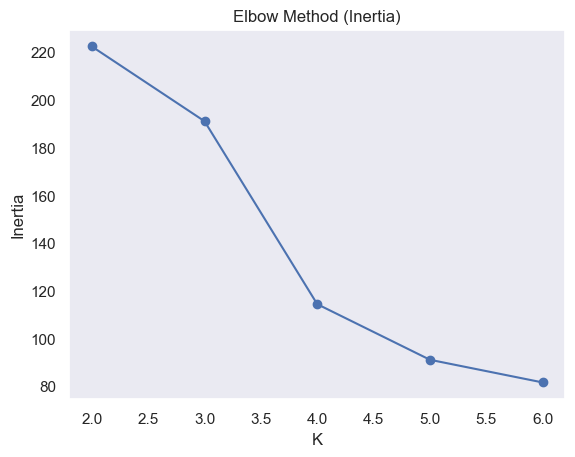

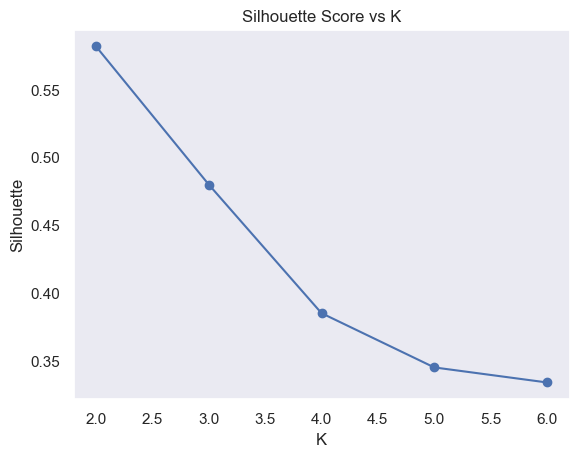

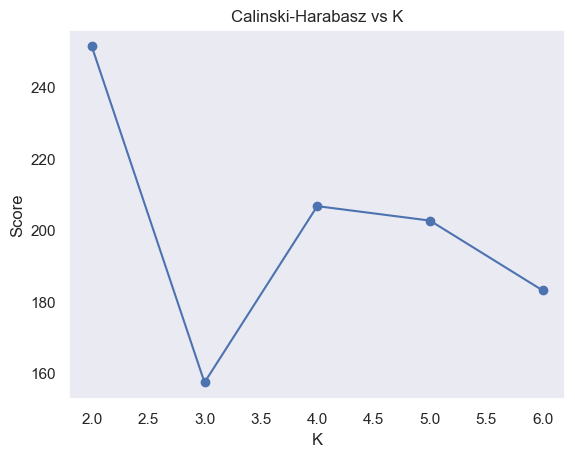

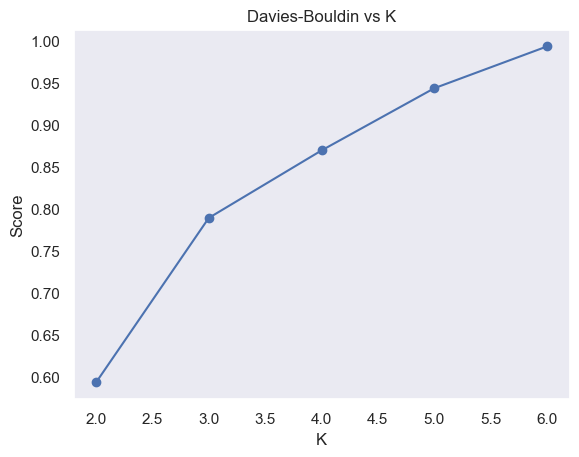

In [7]:
plt.figure()
plt.plot(k_values, inertia_list, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid()
plt.show()

plt.figure()
plt.plot(k_values, silhouette_list, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.grid()
plt.show()

plt.figure()
plt.plot(k_values, ch_list, marker='o')
plt.title("Calinski-Harabasz vs K")
plt.xlabel("K")
plt.ylabel("Score")
plt.grid()
plt.show()

plt.figure()
plt.plot(k_values, db_list, marker='o')
plt.title("Davies-Bouldin vs K")
plt.xlabel("K")
plt.ylabel("Score")
plt.grid()
plt.show()

After plotting 4 different metrics to find optimal K, it makes most sense to use k = 2

### Evaluation ###

In [8]:
def evaluate_clustering(X, labels, inertia=None):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters <= 1:
        return {
            "n_clusters": n_clusters,
            "inertia": inertia,
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan
        }

    return {
        "n_clusters": n_clusters,
        "inertia": inertia,
        "silhouette": silhouette_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels)
    }

### K-Means

In [153]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_results = evaluate_clustering(X_scaled, kmeans_labels, inertia=kmeans.inertia_)
kmeans_results


C:\Users\temir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


{'n_clusters': 2,
 'inertia': 222.36170496502308,
 'silhouette': 0.5817500491982808,
 'calinski_harabasz': 251.34933946458108,
 'davies_bouldin': 0.5933126905762435}

In [156]:
kmeans_df = features.copy()
kmeans_df["cluster"] = kmeans_labels

kmeans_feature_means = kmeans_df.groupby("cluster").mean()
kmeans_feature_diff = (kmeans_feature_means.loc[0] - kmeans_feature_means.loc[1]).abs()
kmeans_feature_means

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,6.262,2.872,4.906,1.676
1,5.006,3.428,1.462,0.246


### PAM (K-Med)

In [10]:
initial_medoids = [0, 100]

pam_instance = kmedoids(X_scaled.tolist(), initial_medoids)
pam_instance.process()
pam_clusters = pam_instance.get_clusters()

pam_labels = np.empty(len(X_scaled), dtype=int)
for cluster_id, cluster_points in enumerate(pam_clusters):
    for point_idx in cluster_points:
        pam_labels[point_idx] = cluster_id
pam_results = evaluate_clustering(X_scaled, pam_labels)
pam_results

{'n_clusters': 2,
 'inertia': None,
 'silhouette': 0.5817500491982808,
 'calinski_harabasz': 251.34933946458108,
 'davies_bouldin': 0.5933126905762435}

In [157]:
pam_df = features.copy()
pam_df["cluster"] = pam_labels

pam_feature_means = pam_df.groupby("cluster").mean()
pam_feature_diff = (pam_feature_means.loc[0] - pam_feature_means.loc[1]).abs()
pam_feature_means

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,5.006,3.428,1.462,0.246
1,6.262,2.872,4.906,1.676


### CLARA

In [13]:
def clara(X, n_clusters=2, sample_size=40, n_samples=5):
    best_labels = None
    best_score = float("inf")  # minimize total distance

    for _ in range(n_samples):
        sample_idx = random.sample(range(len(X)), sample_size)
        sample = [X[i] for i in sample_idx]

        initial_medoids = random.sample(range(sample_size), n_clusters)

        pam = kmedoids(sample, initial_medoids)
        pam.process()
        medoids = pam.get_medoids()

        # assign all points to nearest medoid
        labels = []
        for point in X:
            distances = [np.linalg.norm(np.array(point) - np.array(sample[m])) for m in medoids]
            labels.append(np.argmin(distances))

        # compute total cost
        cost = sum(
            np.linalg.norm(np.array(X[i]) - np.array(sample[medoids[labels[i]]]))
            for i in range(len(X))
        )

        if cost < best_score:
            best_score = cost
            best_labels = labels

    return np.array(best_labels)

In [14]:
clara_labels = clara(X_scaled.tolist(), n_clusters=2)

clara_results = evaluate_clustering(X_scaled, clara_labels)
clara_results

{'n_clusters': 2,
 'inertia': None,
 'silhouette': 0.5817500491982808,
 'calinski_harabasz': 251.34933946458108,
 'davies_bouldin': 0.5933126905762435}

This implementation I found online and used ChatGPT to interpret it to me.

In [158]:
clara_df = features.copy()
clara_df["cluster"] = clara_labels

clara_feature_means = clara_df.groupby("cluster").mean()
clara_feature_diff = (clara_feature_means.loc[0] - clara_feature_means.loc[1]).abs()
clara_feature_means

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,5.006,3.428,1.462,0.246
1,6.262,2.872,4.906,1.676


### CLARANS

In [21]:
clarans_instance = clarans(X_scaled.tolist(), number_clusters=2, numlocal=3, maxneighbor=6)
clarans_instance.process()

clarans_clusters = clarans_instance.get_clusters()
clarans_labels = np.empty(len(X_scaled), dtype=int)

for cluster_id, cluster_points in enumerate(clarans_clusters):
    for point_idx in cluster_points:
        clarans_labels[point_idx] = cluster_id

clarans_results = evaluate_clustering(X_scaled, clarans_labels)
clarans_results

{'n_clusters': 2,
 'inertia': None,
 'silhouette': 0.5817500491982808,
 'calinski_harabasz': 251.34933946458108,
 'davies_bouldin': 0.5933126905762435}

In [159]:
clarans_df = features.copy()
clarans_df["cluster"] = clarans_labels

clarans_feature_means = clarans_df.groupby("cluster").mean()
clarans_feature_diff = (clarans_feature_means.loc[0] - clarans_feature_means.loc[1]).abs()
clarans_feature_means

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,5.006,3.428,1.462,0.246
1,6.262,2.872,4.906,1.676


### Hierarchical (Agglomerative)

In [48]:
agg = AgglomerativeClustering(n_clusters=2, linkage='average')
agg_labels = agg.fit_predict(X_scaled)

agg_results = evaluate_clustering(X_scaled, agg_labels)
agg_results

{'n_clusters': 2,
 'inertia': None,
 'silhouette': 0.5817500491982808,
 'calinski_harabasz': 251.34933946458108,
 'davies_bouldin': 0.5933126905762435}

In [160]:
agg_df = features.copy()
agg_df["cluster"] = agg_labels

agg_feature_means = agg_df.groupby("cluster").mean()
agg_feature_diff = (agg_feature_means.loc[0] - agg_feature_means.loc[1]).abs()
agg_feature_means

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,6.262,2.872,4.906,1.676
1,5.006,3.428,1.462,0.246


### DBSCAN

In [58]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

dbscan_results = evaluate_clustering(X_scaled, dbscan_labels)
dbscan_results

{'n_clusters': 2,
 'inertia': None,
 'silhouette': 0.5817500491982808,
 'calinski_harabasz': 251.34933946458108,
 'davies_bouldin': 0.5933126905762435}

In [161]:
dbscan_df = features.copy()
dbscan_df["cluster"] = dbscan_labels

# remove noise points (-1)
dbscan_df = dbscan_df[dbscan_df["cluster"] != -1]

dbscan_feature_means = dbscan_df.groupby("cluster").mean()
dbscan_feature_diff = (dbscan_feature_means.loc[0] - dbscan_feature_means.loc[1]).abs()
dbscan_feature_means

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,5.006,3.428,1.462,0.246
1,6.262,2.872,4.906,1.676


### SOM

In [122]:
som = MiniSom(x=2, y=1, input_len=X_scaled.shape[1], sigma=1.0, learning_rate=0.5)

som.random_weights_init(X_scaled)
som.train(X_scaled, 354)

som_labels = np.array([som.winner(x)[0] for x in X_scaled])

som_results = evaluate_clustering(X_scaled, som_labels)
som_results

{'n_clusters': 2,
 'inertia': None,
 'silhouette': 0.5817500491982808,
 'calinski_harabasz': 251.34933946458108,
 'davies_bouldin': 0.5933126905762435}

In [162]:
som_df = features.copy()
som_df["cluster"] = som_labels

som_feature_means = som_df.groupby("cluster").mean()
som_feature_diff = (som_feature_means.loc[0] - som_feature_means.loc[1]).abs()
som_feature_means

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,6.262,2.872,4.906,1.676
1,5.006,3.428,1.462,0.246


### Interpreting the Results

After tuning the parameters for each model, I came to a conclusion that the data was split evenly and identically for each method. Which means that 2 clusters was a good solution. If we compare the scores:
* Silhouette = 058
  - Range from -1 to 1
  - The score is closer to 1, so the clusters are good
* Calinski-Harabasz = 251
  - Range normally 0-300+
  - The score is upper middle, so its good
* Davies-Boulding = 0.59
  - The lower, the better, so 0.59 is good

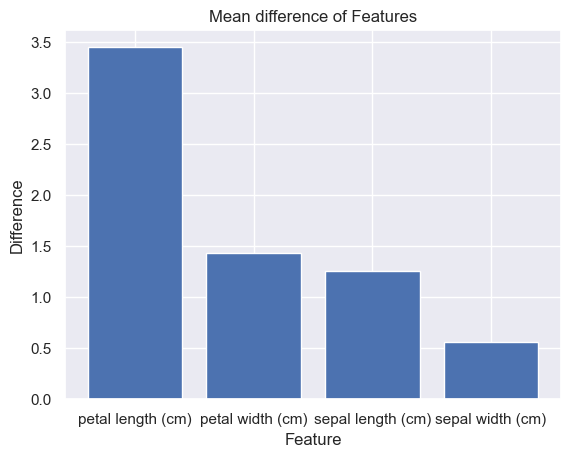

In [143]:
all_diffs = [
    kmeans_feature_diff,
    pam_feature_diff,
    clara_feature_diff,
    clarans_feature_diff,
    agg_feature_diff,
    dbscan_feature_diff,
    som_feature_diff
]
diff_df = pd.concat(all_diffs, axis=1)
avg_diff = diff_df.mean(axis=1)
avg_diff = avg_diff.sort_values(ascending=False)

plt.figure()
plt.bar(avg_diff.index, avg_diff.values)
plt.title('Mean difference of Features')
plt.xlabel('Feature')
plt.ylabel('Difference')
plt.show()

After combining each mean difference between clusters, we can see that petal length and width are 2 features that differ the most. It is safe to come to conclusion that they played the most crucial role for models to identify the clusters